Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
VIF:
             feature        VIF
0  Order_Demand_Log  11.896784
1              MA_7  33.964978
2             STD_7   9.237021
3             Lag_1  11.816997
X_train: (239, 30, 7), X_test: (11, 30, 7)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_loss improved from inf to 0.06112, saving model to /content/drive/MyDrive/checkpoints/best_model.h5


Epoch 1 complete.

Epoch 2: val_loss improved from 0.06112 to 0.06106, saving model to /content/drive/MyDrive/checkpoints/best_model.h5


Epoch 2 complete.

Epoch 3: val_loss improved from 0.06106 to 0.06098, saving model to /content/drive/MyDrive/checkpoints/best_model.h5


Epoch 3 complete.

Epoch 4: val_loss did not improve from 0.06098
Epoch 4 complete.

Epoch 5: val_loss did not improve from 0.06098
Epoch 5 complete.

Epoch 6: val_loss did not improve from 0.06098
Epoch 6 complete.

Epoch 7: val_loss did not improve from 0.06098
Epoch 7 complete.

Epoch 8: val_loss did not improve from 0.06098
Epoch 8 complete.

Epoch 9: val_loss improved from 0.06098 to 0.06095, saving model to /content/drive/MyDrive/checkpoints/best_model.h5


Epoch 9 complete.

Epoch 10: val_loss did not improve from 0.06095
Epoch 10 complete.

Epoch 11: val_loss did not improve from 0.06095
Epoch 11 complete.

Epoch 12: val_loss did not improve from 0.06095
Epoch 12 complete.

Epoch 13: val_loss did not improve from 0.06095
Epoch 13 complete.

Epoch 14: val_loss did not improve from 0.06095
Epoch 14 complete.

Epoch 15: val_loss did not improve from 0.06095
Epoch 15 complete.

Epoch 16: val_loss did not improve from 0.06095
Epoch 16 complete.

Epoch 17: val_loss did not improve from 0.06095
Epoch 17 complete.

Epoch 18: val_loss did not improve from 0.06095
Epoch 18 complete.

Epoch 19: val_loss did not improve from 0.06095
Epoch 19 complete.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step

MAE: 0.38, RMSE: 0.44


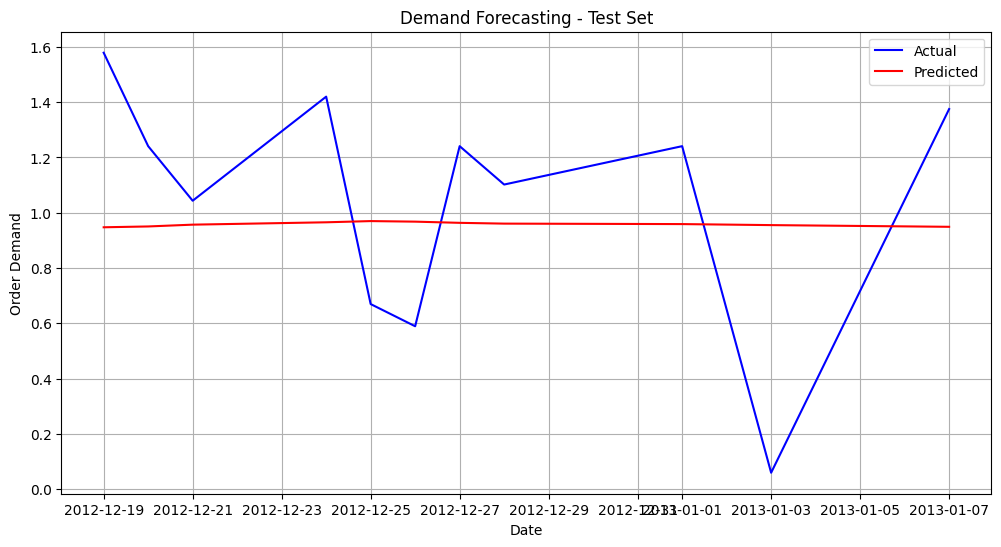

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


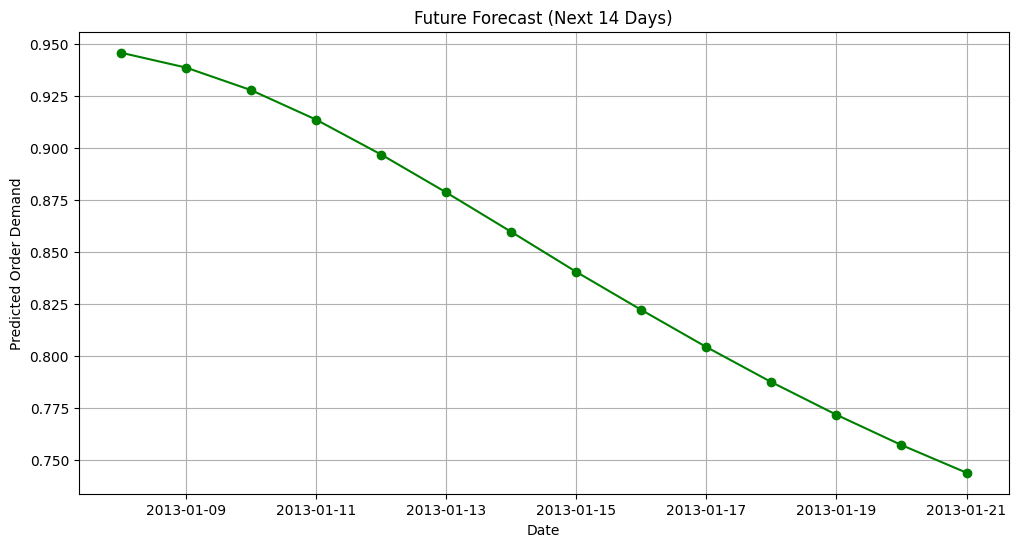

In [ ]:
# Install dependencies
!pip install pandas numpy scikit-learn statsmodels matplotlib h5py tensorflow --quiet

# Mount Google Drive (for file access and saving models)
from google.colab import drive
drive.mount('/content/drive')

# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Setup
SEQ_LENGTH = 30
SPLIT_DAYS = 60
TARGET_COL = 'Order_Demand_Log'
FUTURE_DAYS = 14
np.random.seed(42)
tf.random.set_seed(42)

# Confirm GPU
print("Using device:", tf.config.list_physical_devices('GPU'))

# Load your dataset from Drive (adjust path as needed)
csv_path = '/content/Historical Product Demand.csv'  # <-- Adjust if needed
df = pd.read_csv(csv_path, parse_dates=['Date'], index_col='Date', low_memory=False)
df = df[['Order_Demand']]

# Remove duplicate timestamps & sort
df = df[~df.index.duplicated(keep='first')].sort_index()

# Feature Engineering
df[TARGET_COL] = np.log1p(df['Order_Demand'])
df['MA_7'] = df[TARGET_COL].rolling(7).mean()
df['STD_7'] = df[TARGET_COL].rolling(7).std()
df['Lag_1'] = df[TARGET_COL].shift(1)
df['DayOfWeek'] = df.index.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Month'] = df.index.month
df.dropna(inplace=True)

# VIF check
features = ['Order_Demand_Log', 'MA_7', 'STD_7', 'Lag_1']
X_vif = df[features]
vif_df = pd.DataFrame({
    'feature': features,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(features))]
})
print("VIF:\n", vif_df)

to_drop = vif_df[vif_df['VIF'] > 15]['feature'].tolist()
to_drop = [f for f in to_drop if f != TARGET_COL]
df.drop(columns=to_drop, inplace=True)

# Scale features
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)

# Train/Test split using boolean mask (safe for duplicate indices)
test_start = df_scaled.index.max() - pd.Timedelta(days=SPLIT_DAYS)
train_df = df_scaled[df_scaled.index <= test_start]
test_df  = df_scaled[df_scaled.index > test_start]

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i:i+seq_length].values)
        y.append(data.iloc[i+seq_length][TARGET_COL])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df, SEQ_LENGTH)
X_test, y_test   = create_sequences(test_df, SEQ_LENGTH)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
if len(X_test) == 0 or len(X_train) == 0:
    raise ValueError("Insufficient sequences generated. Try reducing SEQ_LENGTH or adjusting SPLIT_DAYS.")

# Model
def build_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(LSTM(64))
    model.add(Dropout(0.1))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss=MeanSquaredError())
    return model

# Model path
checkpoint_dir = '/content/drive/MyDrive/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = f"{checkpoint_dir}/best_model.h5"

# Callbacks
callbacks = [
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.LambdaCallback(on_epoch_end=lambda epoch, logs: print(f"Epoch {epoch+1} complete."))
]

# Train or Load
if os.path.exists(checkpoint_path):
    model = load_model(checkpoint_path)
    print("Loaded model from checkpoint.")
else:
    model = build_model(input_shape=(SEQ_LENGTH, X_train.shape[2]))
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=0
    )

# Predict & Evaluate
y_pred = model.predict(X_test).flatten()
y_pred_inv = np.expm1(y_pred)
y_test_inv = np.expm1(y_test)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"\nMAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Plot
plt.figure(figsize=(12,6))
idx = test_df.index[SEQ_LENGTH:]
plt.plot(idx, y_test_inv, label="Actual", color="blue")
plt.plot(idx, y_pred_inv, label="Predicted", color="red")
plt.title("Demand Forecasting - Test Set")
plt.xlabel("Date")
plt.ylabel("Order Demand")
plt.legend()
plt.grid(True)
plt.show()

# Future Forecasting
future_preds = []
current_input = df_scaled[-SEQ_LENGTH:].copy()
for _ in range(FUTURE_DAYS):
    input_array = current_input.values.reshape(1, SEQ_LENGTH, -1)
    next_pred = model.predict(input_array)[0][0]
    next_row = current_input.iloc[-1].copy()
    next_row[TARGET_COL] = next_pred
    current_input = pd.concat([
        current_input.iloc[1:],
        pd.DataFrame([next_row], index=[current_input.index[-1] + pd.Timedelta(days=1)])
    ])
    future_preds.append(np.expm1(next_pred))

future_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=FUTURE_DAYS)
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_preds, marker='o', color='green')
plt.title("Future Forecast (Next 14 Days)")
plt.xlabel("Date")
plt.ylabel("Predicted Order Demand")
plt.grid(True)
plt.show()


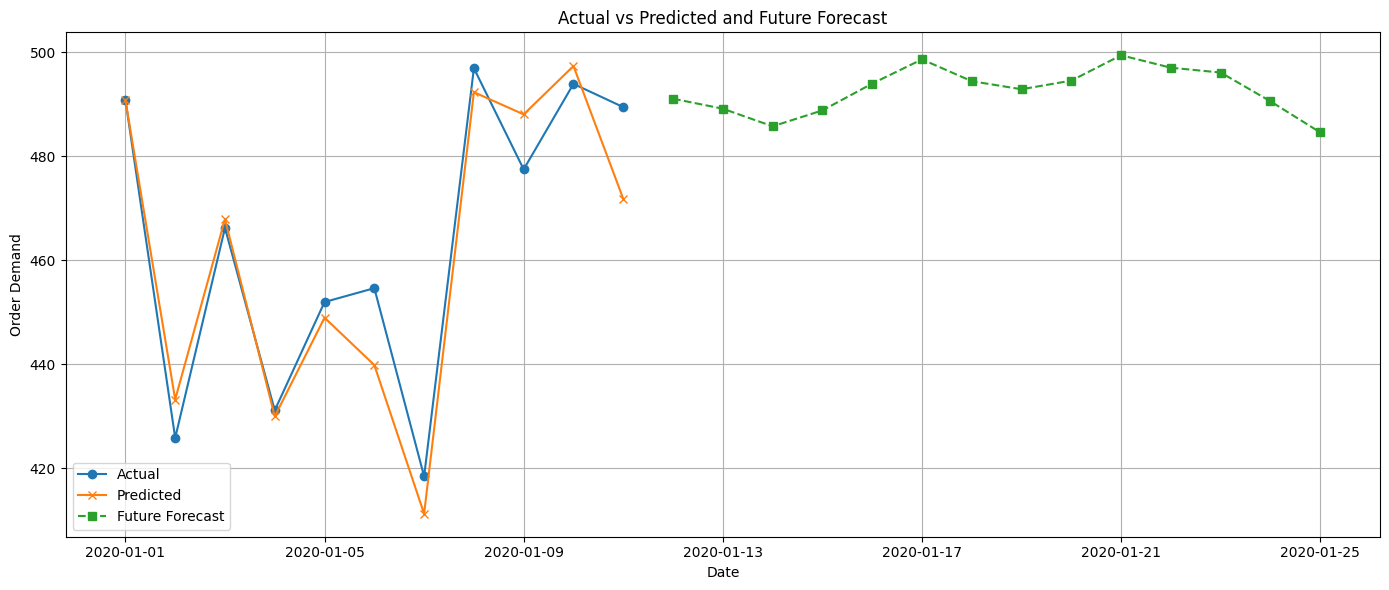

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate sample data (replace with your actual predictions and forecasts)
# Actual y_test and predicted y_pred_inv
dates_test = pd.date_range(start="2020-01-01", periods=11, freq="D")
y_test_inv = np.random.uniform(400, 500, size=11)
y_pred_inv = y_test_inv + np.random.normal(0, 10, size=11)

# Future forecast
future_dates = pd.date_range(start=dates_test[-1] + pd.Timedelta(days=1), periods=14, freq="D")
future_forecast = y_test_inv[-1] + np.cumsum(np.random.normal(0, 5, size=14))

# Save to CSV
results_df = pd.DataFrame({
    "Date": dates_test,
    "Actual": y_test_inv,
    "Predicted": y_pred_inv
})
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_forecast
})

results_df.to_csv("/content/predictions.csv", index=False)
forecast_df.to_csv("/content/future_forecast.csv", index=False)

# Plot
plt.figure(figsize=(14,6))
plt.plot(results_df["Date"], results_df["Actual"], label="Actual", marker='o')
plt.plot(results_df["Date"], results_df["Predicted"], label="Predicted", marker='x')
plt.plot(forecast_df["Date"], forecast_df["Forecast"], label="Future Forecast", marker='s', linestyle='--')
plt.title("Actual vs Predicted and Future Forecast")
plt.xlabel("Date")
plt.ylabel("Order Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/forecast_plot.png")
plt.show()
